# Arguments and shapes

Pick the plane type that matches your data — a vector, a matrix, a
quaternion — and see how a batch of samples is laid out in memory.

**Time:** ~8 min · **Runs on:** CPU · **You need:**
[Your first kernel](01_your_first_kernel)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import plot_style
plot_style()


## A per-sample vector

`Vector[3]` declares a 3-component per-sample input — a velocity, a
position, anything with 3 numbers per sample. `hawk.math.cross` is
ordinary vector algebra written against two of them. Build and run it
the same way [Your first kernel](01_your_first_kernel) does:


In [2]:
import numpy as np

import hawk
from hawk import Mutable, Vector
from hawk.math import cross


@hawk.kernel
def cross_product(a: Vector[3], b: Vector[3], out: Mutable[Vector[3]]):
    out = cross(a, b)


cross_product


<Kernel cross_product slots=3>

`hawk.artifact.build` + `hawk.load`/`hawk.run` compile and run it on the host:


In [3]:
import pathlib, tempfile

import hawk.artifact

work_dir = pathlib.Path(tempfile.mkdtemp())
a = np.array([[1.0, 0.0], [0.0, 1.0], [0.0, 0.0]])   # one column per sample
b = np.array([[0.0, 1.0], [1.0, 0.0], [0.0, 0.0]])
out = np.zeros((3, 2))
hawk.artifact.build(cross_product, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "cross_product"), a=a, b=b, out=out)
print("a x b =\n", out)


a x b =
 [[ 0.  0.]
 [ 0.  0.]
 [ 1. -1.]]


Two samples went in (`a`, `b` each hold 2 columns) and two cross products
came out — every plane here already batches over samples, one kernel call
covers the whole set.

**Try this:** swap `cross(a, b)` for `hawk.math.dot(a, b)` and change
`out`'s annotation to `Mutable[Scalar]` — same two inputs, a different
vocabulary word, a different shape of result.

## A per-sample matrix

`Matrix[3, 3]` declares a 3x3 per-sample input, such as a rotation or an
inertia tensor. `@` is matrix-vector multiplication, the same operator
NumPy uses.

In [4]:
from hawk import Matrix

@hawk.kernel
def rotate_by_matrix(spin: Matrix[3, 3], a: Vector[3], out: Mutable[Vector[3]]):
    out = spin @ a


spin = np.tile((2.0 * np.eye(3)).reshape(9, 1), (1, 2))   # see below: why (9, 2)
out = np.zeros((3, 2))
hawk.artifact.build(rotate_by_matrix, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "rotate_by_matrix"), spin=spin, a=a, out=out)
print("spin @ a =\n", out)


spin @ a =
 [[2. 0.]
 [0. 2.]
 [0. 0.]]


## Why the matrix array is shaped `(9, n)`

A `Matrix[R, C]` plane is **flat**, `(R*C, n)`, never `(R, C, n)` — one
row per matrix entry, in row-major order, same as every other plane
keeping one row per component. The same `np.eye(3)` reused for both
samples above hid that; here each sample gets a genuinely different
matrix, built by flattening a `(n, 3, 3)` array:

In [5]:
spins = [np.eye(3), np.diag([1.0, -1.0, 1.0])]            # two DIFFERENT 3x3 matrices
spin_flat = np.stack([m.ravel() for m in spins], axis=1)  # flatten, stack as columns

out2 = np.zeros((3, 2))
hawk.artifact.build(rotate_by_matrix, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "rotate_by_matrix"), spin=spin_flat, a=a, out=out2)
print("spin @ a (two different matrices) =\n", out2)


spin @ a (two different matrices) =
 [[ 1.  0.]
 [ 0. -1.]
 [ 0.  0.]]


## Combining what you have

`triad` below reuses `cross` and `@` from the cells above, plus one new
one-liner, `hawk.math.dot` (the dot product) — three named outputs from
one kernel, reusing the `a`, `b` and `spin` arrays already built above.

In [6]:
from hawk import Scalar
from hawk.math import dot

@hawk.kernel
def triad(a: Vector[3], b: Vector[3], spin: Matrix[3, 3],
          perp: Mutable[Vector[3]], along: Mutable[Scalar],
          spun: Mutable[Vector[3]]):
    perp = cross(a, b)
    along = dot(a, b)
    spun = spin @ a


triad


<Kernel triad slots=6>

Build and run it the same way:


In [7]:
perp, along, spun = np.zeros((3, 2)), np.zeros(2), np.zeros((3, 2))
hawk.artifact.build(triad, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "triad"), a=a, b=b, spin=spin,
       perp=perp, along=along, spun=spun)
print("a x b   =\n", perp)
print("a . b   =", along)
print("spin @ a =\n", spun)


a x b   =
 [[ 0.  0.]
 [ 0.  0.]
 [ 1. -1.]]
a . b   = [0. 0.]
spin @ a =
 [[2. 0.]
 [0. 2.]
 [0. 0.]]


## A quaternion rotates a vector

`Quat` is a plain 4-component plane, like any other; `quat_rotate(q, v)`
rotates `v` by `q`.

In [8]:
from hawk import Quat
from hawk.math import quat_rotate


@hawk.kernel
def apply_rotation(q: Quat, v: Vector[3], out: Mutable[Vector[3]]):
    out = quat_rotate(q, v)


apply_rotation


<Kernel apply_rotation slots=3>

Build and run it on a single sample:


In [9]:
# a 90-degree rotation about z: q = (cos45, 0, 0, sin45), (w, x, y, z)
q = np.array([[np.cos(np.pi / 4)], [0.0], [0.0], [np.sin(np.pi / 4)]])
v = np.array([[1.0], [0.0], [0.0]])
out = np.zeros((3, 1))
hawk.artifact.build(apply_rotation, work_dir, targets=("host",))
hawk.run(hawk.load(work_dir, "apply_rotation"), q=q, v=v, out=out)
print("rotated (1, 0, 0) by 90 deg about z:", out.ravel())


rotated (1, 0, 0) by 90 deg about z: [2.22044605e-16 1.00000000e+00 0.00000000e+00]


## The same plane, a different array layout

Every vector plane above was **component-major**: `Vector[3]` over `n`
samples is `(3, n)`, one contiguous row per component. Most array code
keeps per-sample vectors the other way round, `(n, 3)`. `hawk.run`
accepts that layout too, with **no copy**, exactly when it is a
transposed view of a component-major array:

In [10]:
from hawk.math import norm

@hawk.kernel
def speed(v: Vector[3], out: Mutable[Scalar]):
    out = norm(v)


speed


<Kernel speed slots=2>

Build it once, then bind both array layouts to the same kernel:


In [11]:
n = 4
v_component_major = np.random.default_rng(0).normal(size=(3, n))   # (3, n)

hawk.artifact.build(speed, work_dir, targets=("host",))
speed_host = hawk.load(work_dir, "speed")
out_a = np.zeros(n)
hawk.run(speed_host, v=v_component_major, out=out_a)

v_sample_major = v_component_major.T        # (n, 3) VIEW, no copy taken
out_b = np.zeros(n)
hawk.run(speed_host, v=v_sample_major, out=out_b)      # bound directly, same bytes
print("same result from (3, n) and its (n, 3) view:", np.allclose(out_a, out_b))
print("zero-copy:", np.shares_memory(v_sample_major, v_component_major))


same result from (3, n) and its (n, 3) view: True
zero-copy: True


A plot makes the `(3, n)` layout concrete — one highlighted column is one
sample, carrying all 3 of its components:

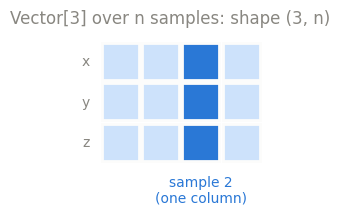

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.2))
labels, highlight = ["x", "y", "z"], 2
for col in range(n):
    for row, label in enumerate(labels):
        face = "#2a78d6" if col == highlight else "#cde2fb"
        ax.add_patch(plt.Rectangle((col, 2 - row), 0.92, 0.92, facecolor=face,
                                   edgecolor="#fcfcfb", linewidth=2))
        if col == 0:
            ax.text(-0.3, 2 - row + 0.46, label, ha="right", va="center", color="#898781")
ax.text(highlight + 0.46, -0.35, f"sample {highlight}\n(one column)",
        ha="center", va="top", color="#2a78d6")
ax.set_xlim(-0.6, n); ax.set_ylim(-1.0, 3.2)
ax.set_title("Vector[3] over n samples: shape (3, n)", color="#898781")
ax.set_aspect("equal"); ax.axis("off")
plt.show()

Any other `(n, 3)` array (a plain C-contiguous one, say) would need a
real copy, so `hawk.run` refuses it outright rather than silently
copying — naming the argument and the fix
(`np.ascontiguousarray(x.T)`), per [Interoperability](../interop).

## What just happened

- `Vector[3]`, `Matrix[3, 3]` and `Quat` declare per-sample inputs the same
  way `Scalar` does; `hawk.math.{cross, dot, norm, quat_rotate}` write the
  vector algebra a body needs, and a kernel can combine several of them
  into one call with several named outputs.
- A `Matrix[R, C]` plane is flat (`(R*C, n)`), built by flattening each
  sample's matrix and stacking the flattened rows as columns — never a
  3-D array.
- `hawk.run` also binds the **sample-major** `(n, 3)` layout most array
  code uses, with no copy, exactly when it is a transposed view of a
  component-major array.

## Going deeper (optional)

A kernel need not commit only through a named `Mutable` parameter: ending
its body with `return <expr>` commits into a slot a declared `Kind` names.
[Writing a vocabulary](../vocabulary/01_a_family_of_kernels) covers `Kind`
in full; this is only the shape of it:

```python
from hawk.ext import Kind, Output

ACCEL = Kind("accel_teaser", output=Output.returned(Vector[3], slot="acc"))

@ACCEL
def tiny_drag(velocity: Vector[3], k: Param):
    return (-k) * velocity    # commits into the synthesised "acc" slot
```

## Next

[Stop when you're done](03_stop_when_youre_done) — write a kernel that
steps itself until each sample finishes, and run one trajectory on the CPU
or a million on the GPU with the same call.